In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet('../data/pue_combined_hourly.parquet')

In [3]:
df.head()

,ts,cooling_kw,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,day,outdoor_air_humidity,outdoor_air_temp
0,2016-06-12 06:00:00,6.248333,4.273333,802.425833,2.371667,1.024600,6.861167,12.0,63.113333,63.530000
1,2016-06-12 07:00:00,5.743333,4.326667,804.580667,2.372167,1.024167,6.994167,12.0,59.163333,65.648333
2,2016-06-12 08:00:00,5.911667,4.286667,804.367833,2.373500,1.024283,6.980667,12.0,63.535000,64.218333
3,2016-06-12 09:00:00,5.093333,4.296667,808.211000,2.454333,1.023333,6.954667,12.0,61.041667,62.581667
4,2016-06-12 10:00:00,4.760000,4.276667,805.996167,2.374500,1.022883,7.017167,12.0,57.791667,63.075000


In [4]:
df.shape

(80773, 10)

<Axes: >

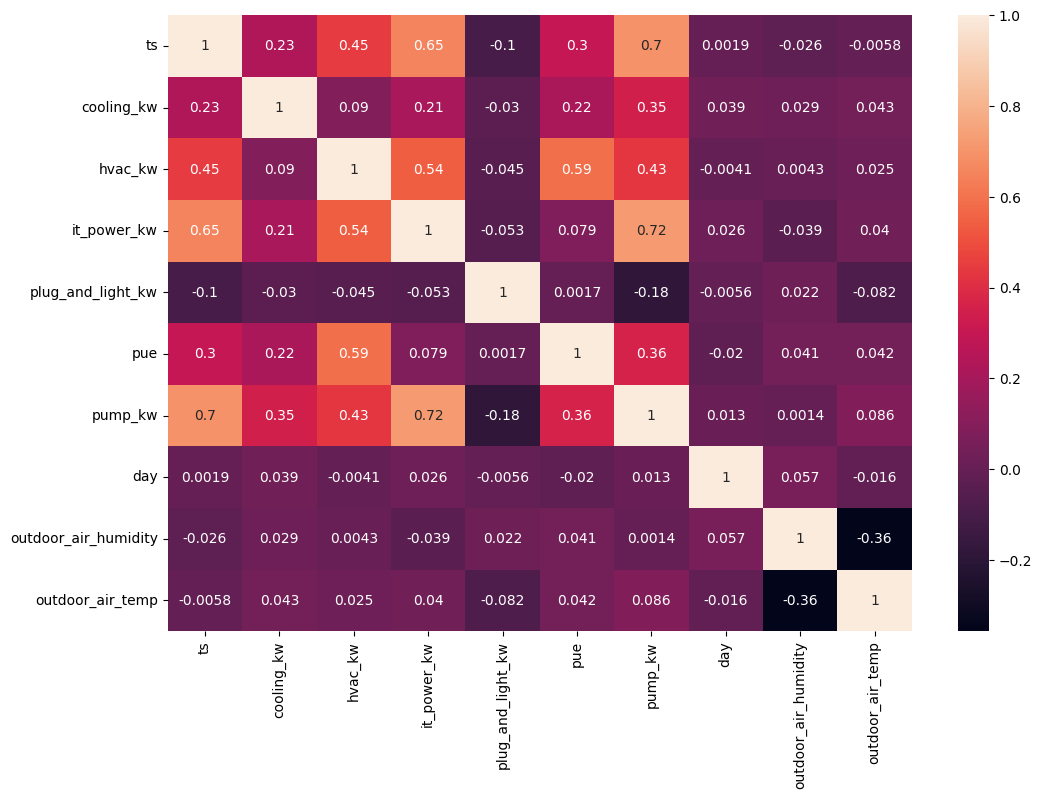

In [20]:
# Correlation
plt.figure(figsize = (12, 8))
sns.heatmap(df.corr(), annot = True)

# Correlated features

**Highly Correlated (±0.7 to ±1.0):**

- ts & pump_kw: 0.70 
- it_power_kw & pump_kw: 0.72 

**Moderately Correlated (±0.3 to ±0.69):**

- ts & it_power_kw: 0.65
- hvac_kw & it_power_kw: 0.54 
- hvac_kw & pump_kw: 0.43 
- hvac_kw & pue: 0.59 
- pue & ts: 0.30 
- pue & pump_kw: 0.36 
- pump_kw & cooling_kw: 0.35 
- outdoor_air_temp & outdoor_air_humidity: -0.36

So, pump load increase clearly over time (2016 - 2025) and so does the facility's compute load. outdoor_air_temp & pue has nearly zero correlation (0.042) and I thought outside temp might drive PUE through cooling load. This weak correlation somewhat suggests either the facility has good free cooling systems that compensate, or the houly resampling smoothed out the relationship. 

# Plots 

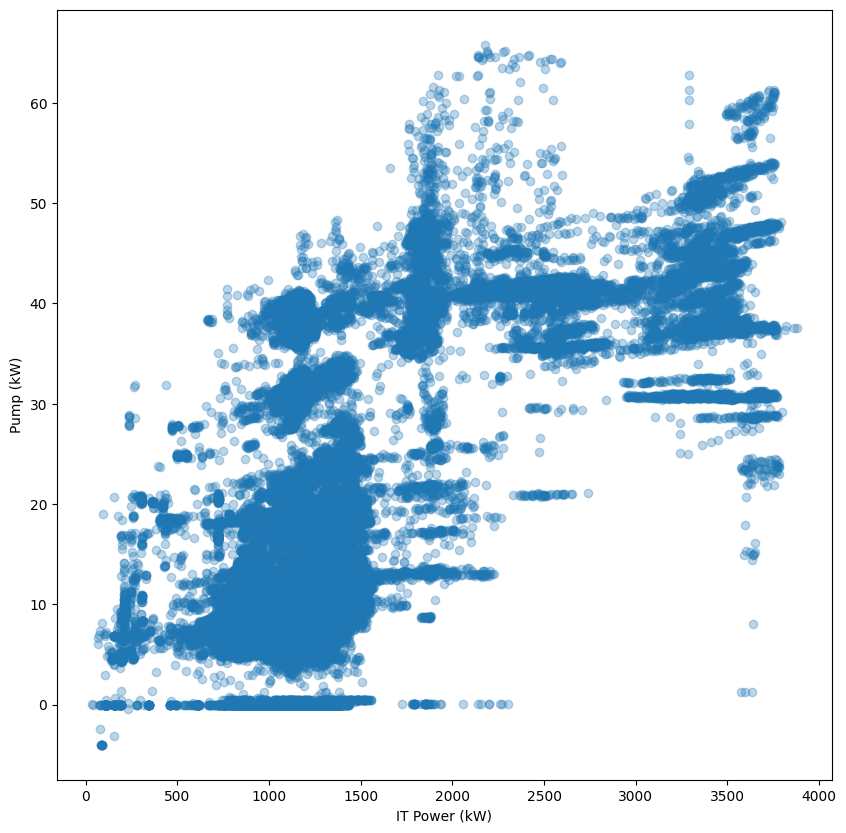

In [36]:
# Compute Load vs Efficiency
plt.figure(figsize = (10, 10))
plt.xlabel('IT Power (kW)')
plt.ylabel('Pump (kW)')
plt.scatter(x=df['it_power_kw'], y=df['pump_kw'], alpha=0.3)

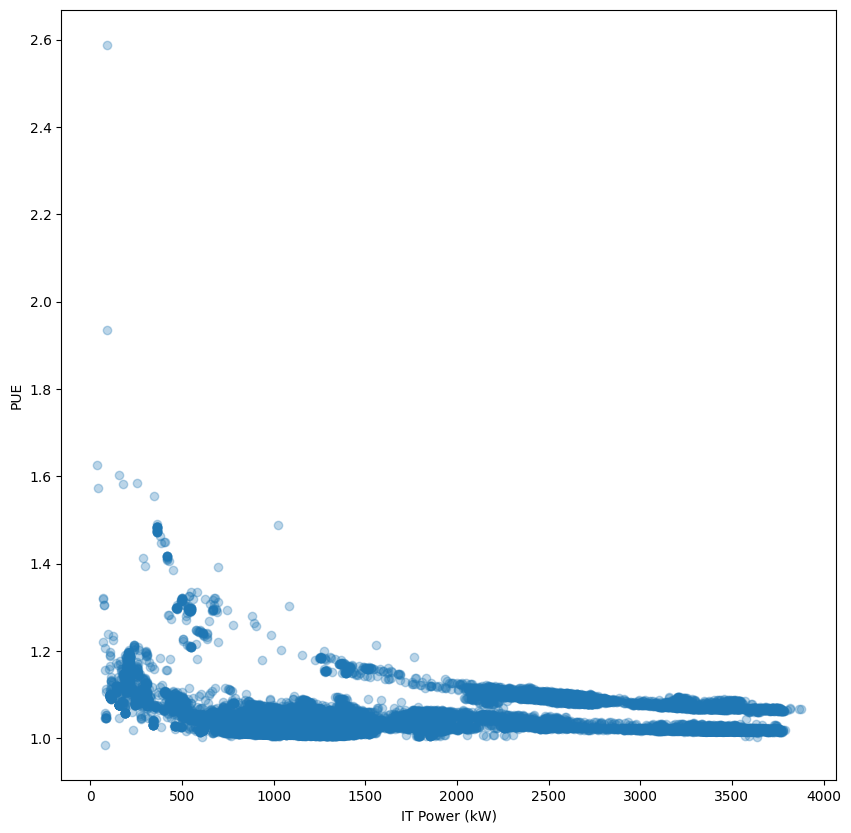

In [42]:
# IT Power (Compute Load) vs PUE
plt.figure(figsize = (10, 10))
plt.xlabel('IT Power (kW)')
plt.ylabel('PUE')
plt.scatter(x=df['it_power_kw'], y=df['pue'], alpha=0.3)

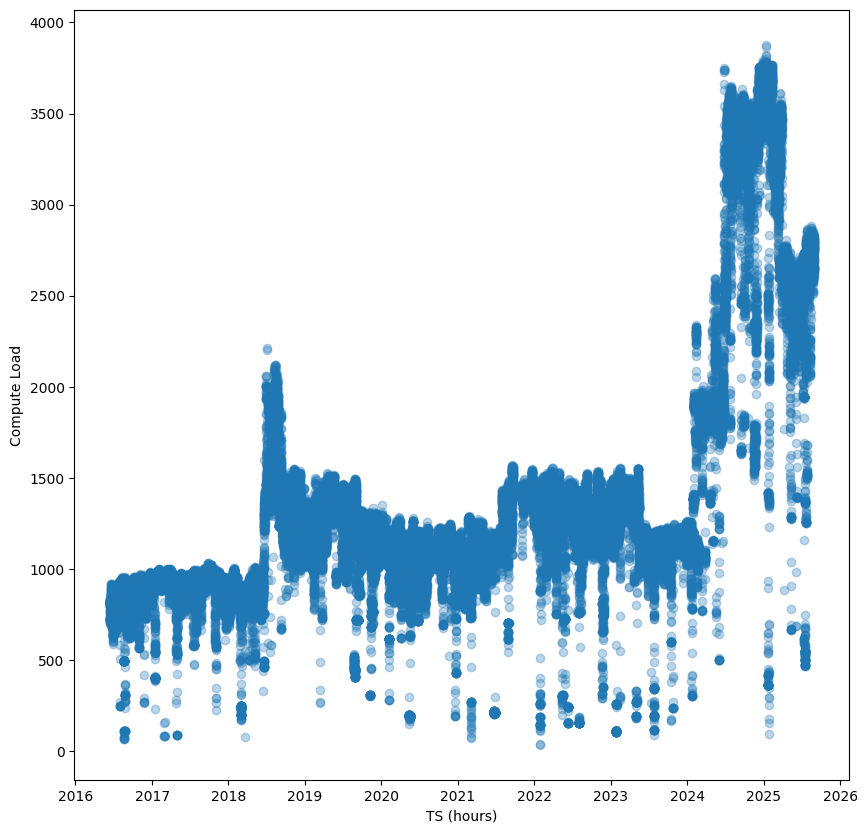

In [41]:
# Compute growth over time
plt.figure(figsize = (10, 10))
plt.xlabel('TS (hours)')
plt.ylabel('Compute Load')
plt.scatter(x=df['ts'], y=df['it_power_kw'], alpha=0.3)

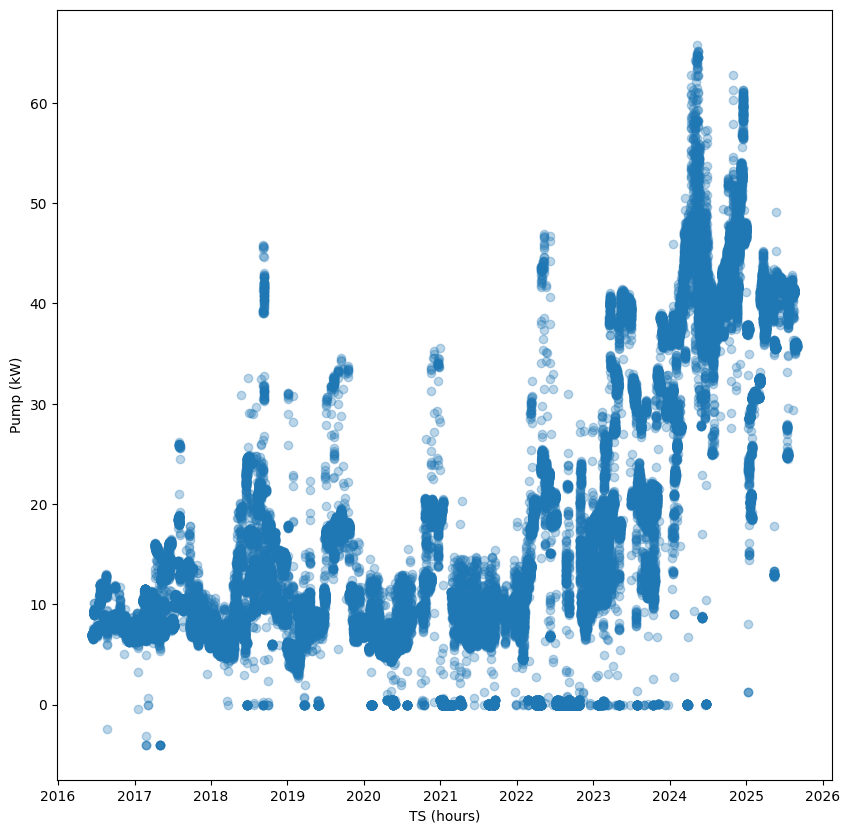

In [37]:
# PUE over time
plt.figure(figsize = (10, 10))
plt.xlabel('TS (hours)')
plt.ylabel('Pump (kW)')
plt.scatter(x=df['ts'], y=df['pump_kw'], alpha=0.3)

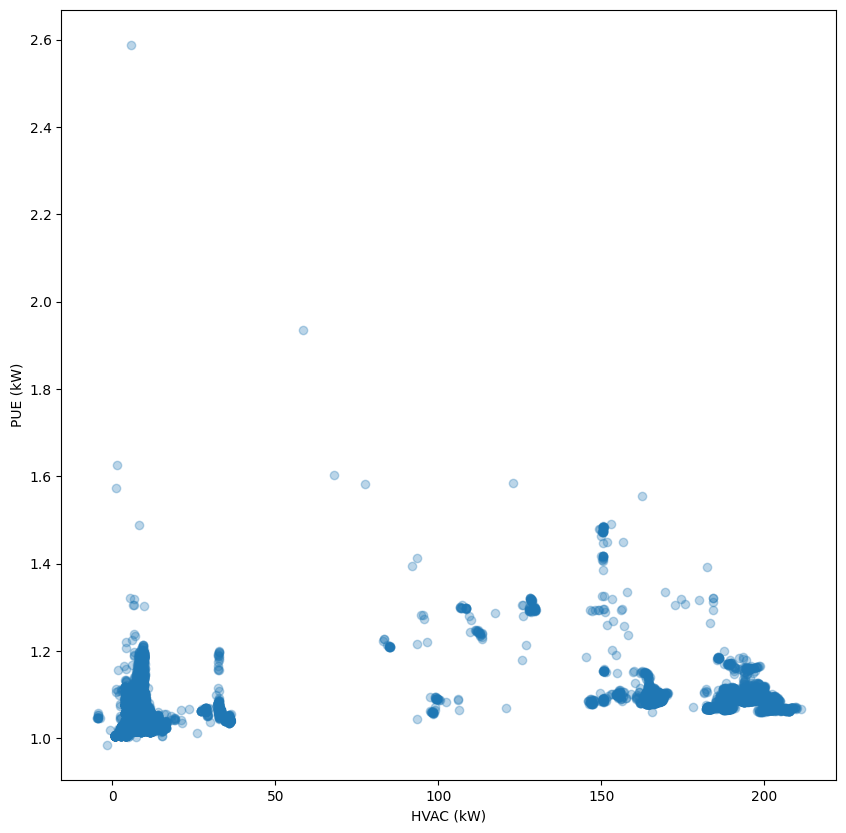

In [38]:
# Cooling overhead driving efficiency
plt.figure(figsize = (10, 10))
plt.xlabel('HVAC (kW)')
plt.ylabel('PUE (kW)')
plt.scatter(x=df['hvac_kw'], y=df['pue'], alpha=0.3)

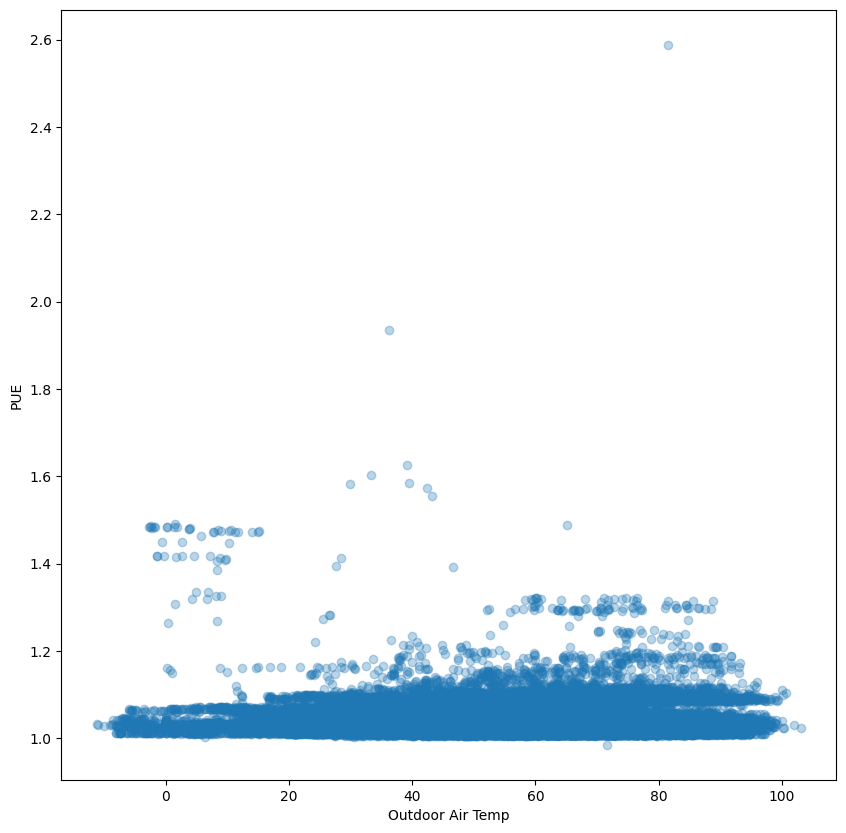

In [39]:
# Not the strongest relationship but this is weather vs efficiency and matters for what I'm modelling
plt.figure(figsize = (10, 10))
plt.xlabel('Outdoor Air Temp')
plt.ylabel('PUE')
plt.scatter(x=df['outdoor_air_temp'], y=df['pue'], alpha=0.3)

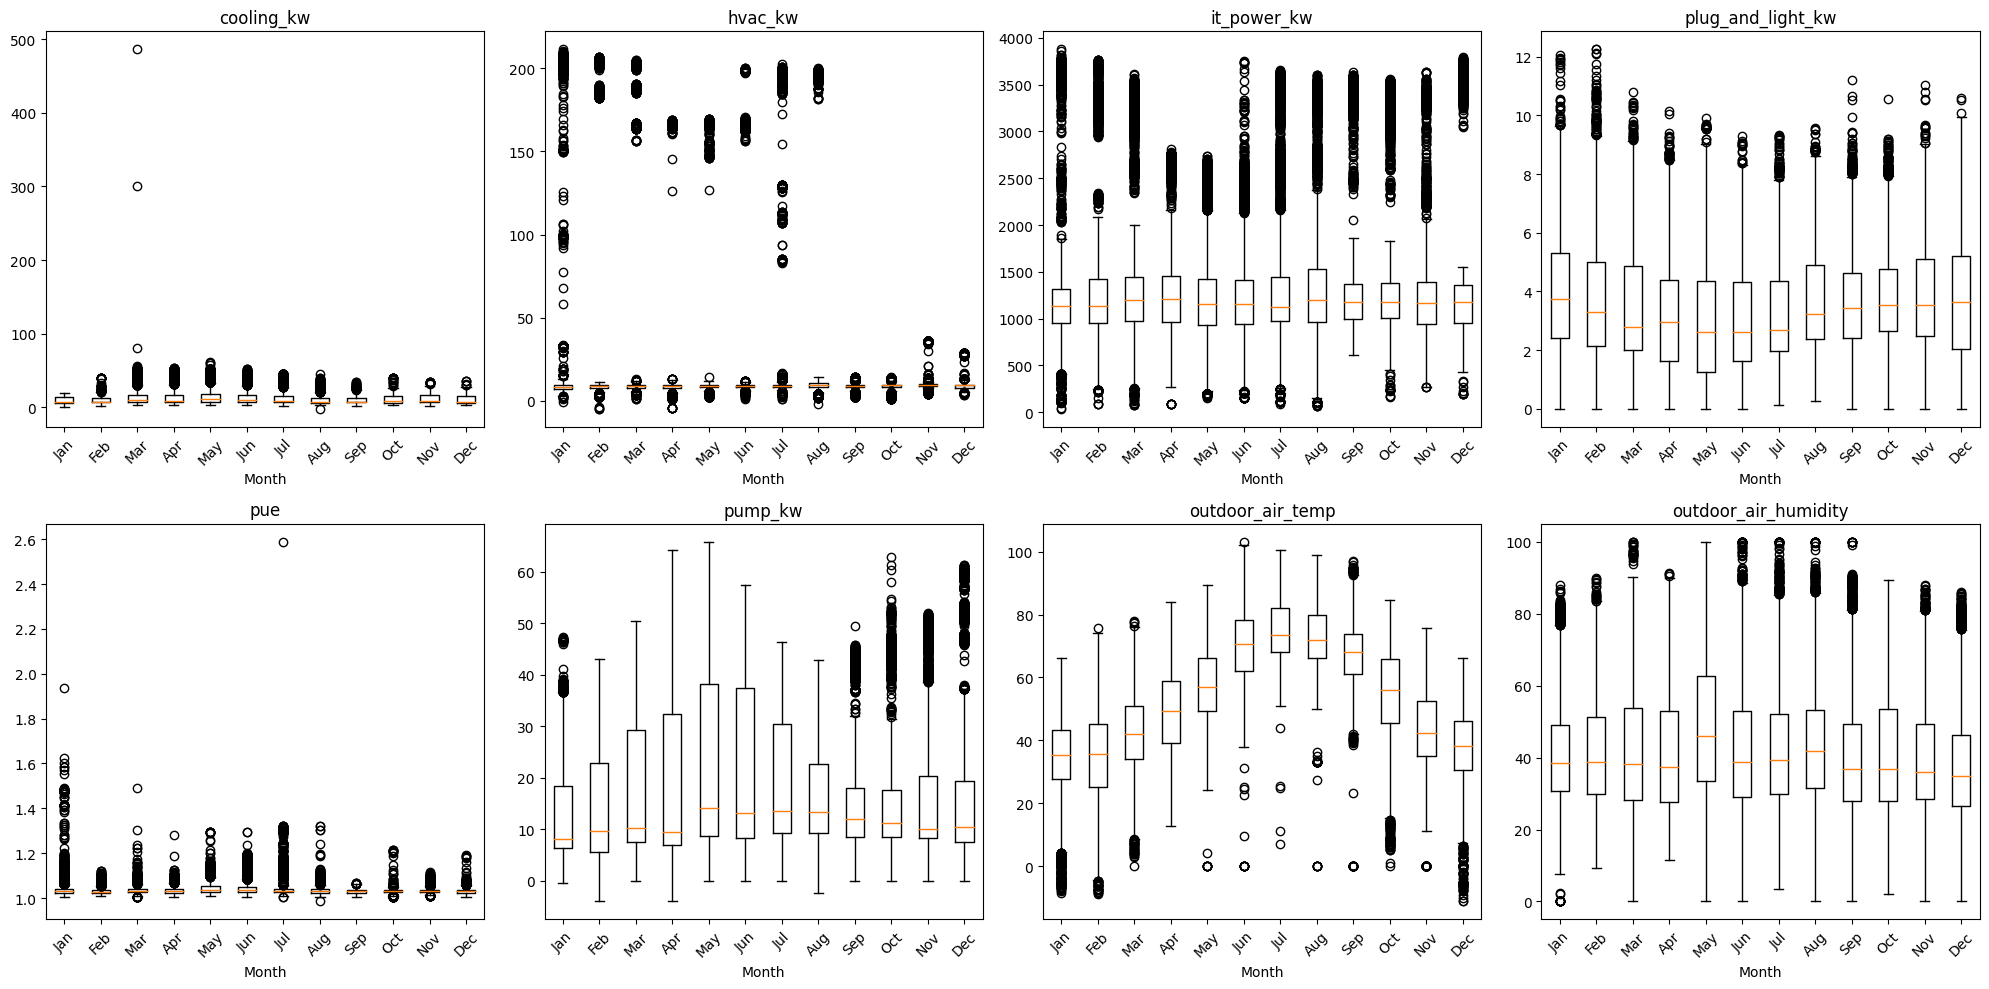

In [44]:
# Create month column
df['month'] = df['ts'].dt.month

numeric_cols = [
    'cooling_kw',
    'hvac_kw',
    'it_power_kw',
    'plug_and_light_kw',
    'pue',
    'pump_kw',
    'outdoor_air_temp',
    'outdoor_air_humidity'
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    monthly_data = [
        df.loc[df['month'] == month, col].dropna()
        for month in range(1, 13)
    ]

    axes[i].boxplot(monthly_data)
    axes[i].set_title(col)
    axes[i].set_xlabel('Month')
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(
        ['Jan','Feb','Mar','Apr','May','Jun',
         'Jul','Aug','Sep','Oct','Nov','Dec'],
        rotation=45
    )

plt.tight_layout()
plt.show()

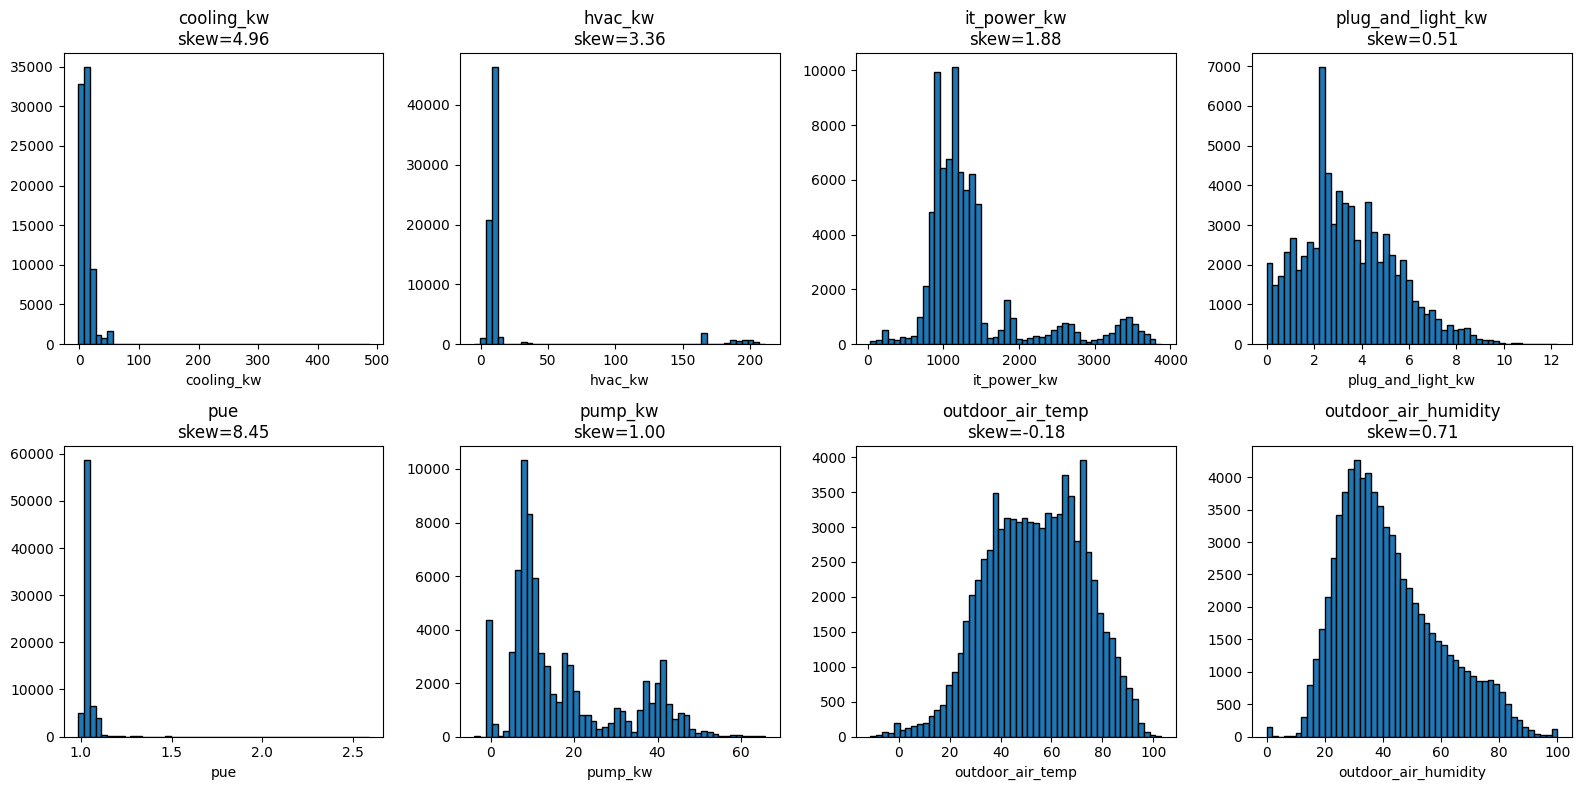

In [22]:
# Histograms (all numeric features)
numeric_cols = ['cooling_kw', 'hvac_kw', 'it_power_kw', 
                'plug_and_light_kw', 'pue', 'pump_kw',
                'outdoor_air_temp', 'outdoor_air_humidity']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=50, edgecolor='black')
    axes[i].set_title(f'{col}\nskew={df[col].skew():.2f}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

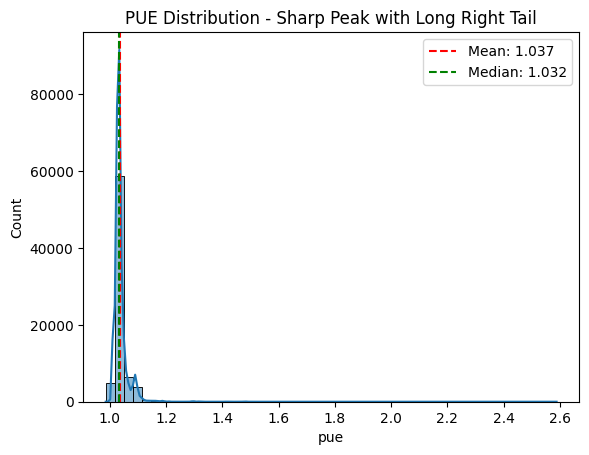

In [25]:
# KDE - target variable and feature keys only
# KDE overlay on PUE histogram - litreally the single most important plot
sns.histplot(df['pue'], kde=True, bins=50)
plt.title('PUE Distribution - Sharp Peak with Long Right Tail')
plt.axvline(df['pue'].mean(), color='red', linestyle='--', label=f'Mean: {df["pue"].mean():.3f}')
plt.axvline(df['pue'].median(), color='green', linestyle='--', label=f'Median: {df["pue"].median():.3f}')
plt.legend()

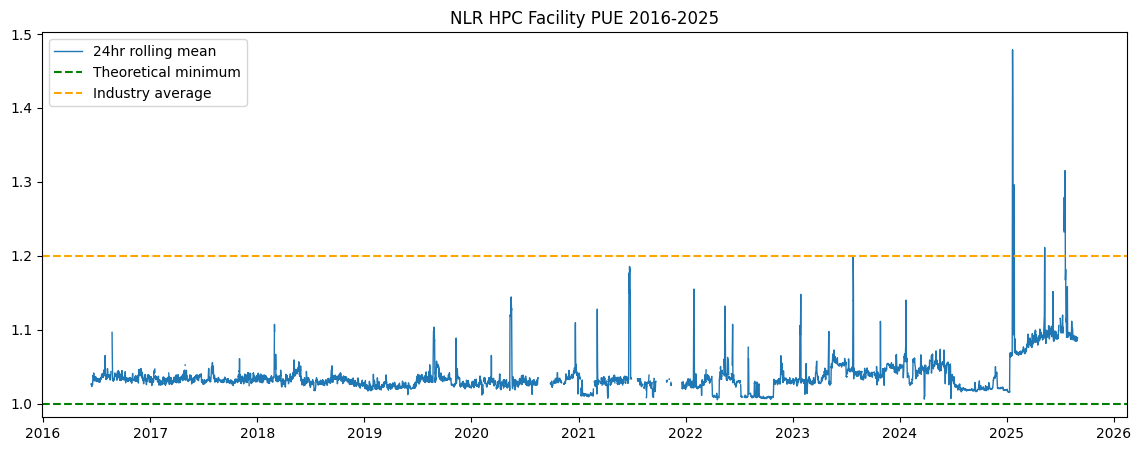

In [26]:
# Time Series Plots
# PUE over time with rolling mean + reference lines (anchor plot)

pue_series = df.set_index('ts')['pue'].sort_index()
rolling = pue_series.rolling(24).mean()

plt.figure(figsize=(14, 5))
plt.plot(pue_series.index, rolling, linewidth=1, label='24hr rolling mean')
plt.axhline(1.0, color='green', linestyle='--', label='Theoretical minimum')
plt.axhline(1.2, color='orange', linestyle='--', label='Industry average')
plt.title('NLR HPC Facility PUE 2016-2025')
plt.legend()

Text(0.5, 1.0, 'IT Power Load Growth 2016-2025 (Weekly Rolling Mean)')

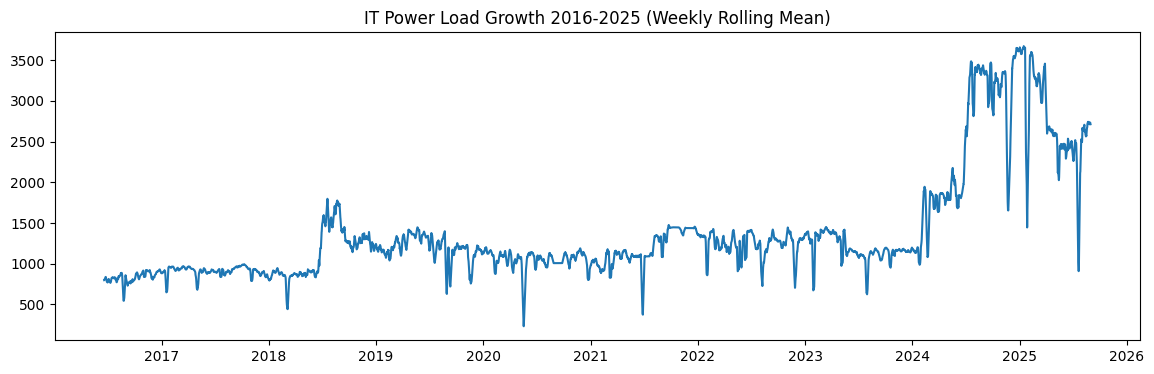

In [28]:
# IT Power load over time -- shows the compute growth trend that explains the ts/it_power_kw correlation
it_series = df.set_index('ts')['it_power_kw'].sort_index()
it_rolling = it_series.rolling(168).mean()  # weekly rolling mean

plt.figure(figsize=(14, 4))
plt.plot(it_series.index, it_rolling)
plt.title('IT Power Load Growth 2016-2025 (Weekly Rolling Mean)')

Text(0.5, 1.0, 'PUE Anomaly Detection — 99th Percentile Threshold')

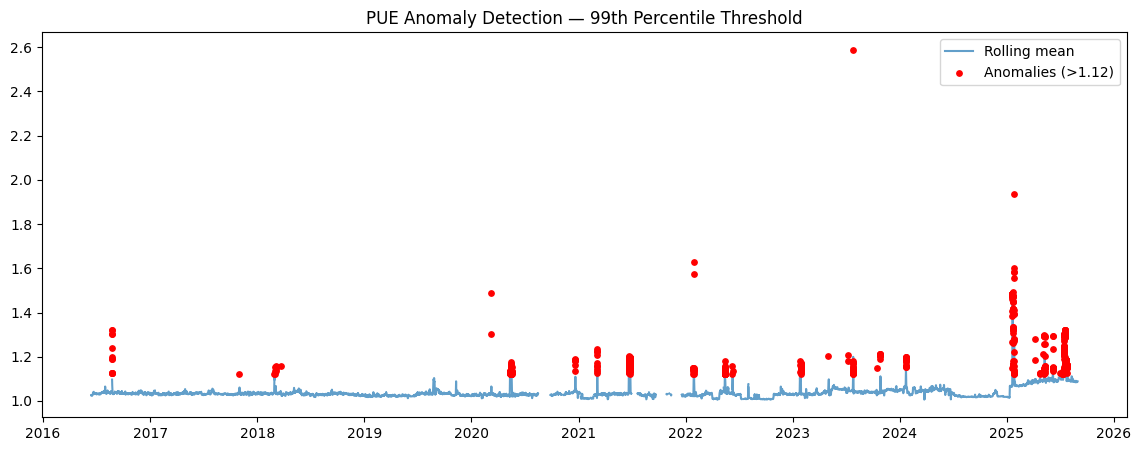

In [29]:
# PUE with anomaly overlay with spikes highlighted in red against normal operating band
threshold = df['pue'].quantile(0.99)
anomalies = df[df['pue'] > threshold]

plt.figure(figsize=(14, 5))
plt.plot(df['ts'], df['pue'].rolling(24).mean(), 
         alpha=0.7, label='Rolling mean')
plt.scatter(anomalies['ts'], anomalies['pue'], 
            color='red', s=15, zorder=5, label=f'Anomalies (>{threshold:.2f})')
plt.legend()
plt.title('PUE Anomaly Detection — 99th Percentile Threshold')

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23]),
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(19, 0, '19'),
  Text(20, 0, '20'),
  Text(21, 0, '21'),
  Text(22, 0, '22'),
  Text(23, 0, '23')])

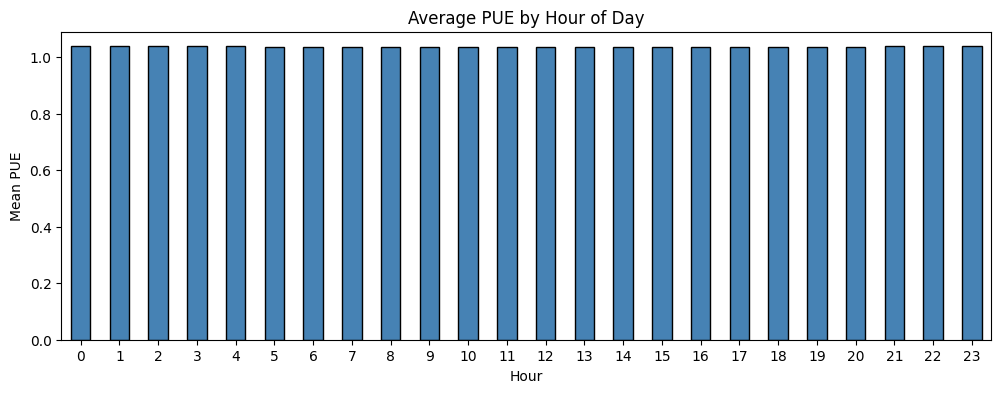

In [30]:
# Average PUE by hour of day (which validates the daily cycle from ACF)
df['hour'] = df['ts'].dt.hour
hourly_pue = df.groupby('hour')['pue'].mean()

plt.figure(figsize=(12, 4))
hourly_pue.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average PUE by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Mean PUE')
plt.xticks(rotation=0)

([<matplotlib.axis.XTick at 0x14b942450>,
 [Text(0, 0, 'Jan'),
  Text(1, 0, 'Feb'),
  Text(2, 0, 'Mar'),
  Text(3, 0, 'Apr'),
  Text(4, 0, 'May'),
  Text(5, 0, 'Jun'),
  Text(6, 0, 'Jul'),
  Text(7, 0, 'Aug'),
  Text(8, 0, 'Sep'),
  Text(9, 0, 'Oct'),
  Text(10, 0, 'Nov'),
  Text(11, 0, 'Dec')])

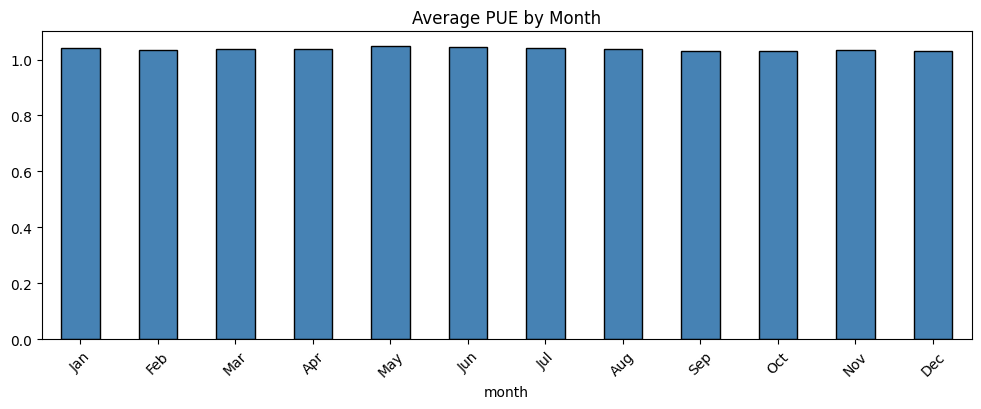

In [31]:
# Average PUE by month which validates the seasonal pattern and outdoor_air_temp hypothesis

df['month'] = df['ts'].dt.month
monthly_pue = df.groupby('month')['pue'].mean()

plt.figure(figsize=(12, 4))
monthly_pue.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average PUE by Month')
plt.xticks(ticks=range(12), 
           labels=['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)